In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv('prophet_연습문제.csv')

display( df.head() )
print()
display( df.tail() )

,ds,y
0,2025-01-01,309.934283
1,2025-01-02,297.679158
2,2025-01-03,313.842660
3,2025-01-04,381.793930
4,2025-01-05,347.094710


,ds,y
176,2025-06-26,378.482260
177,2025-06-27,407.737348
178,2025-06-28,423.817974
179,2025-06-29,483.958939
180,2025-06-30,392.513347


In [5]:
# 2. Prophet 모델 생성
model = Prophet()

# 3. 모델 학습
model.fit(df)

# 4. 미래 14일 날짜 생성
future = model.make_future_dataframe(periods=14)

# 5. 예측
forecast = model.predict(future)

# 6. 전체 예측 결과 중 필요한 컬럼만 확인
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(20))

17:16:56 - cmdstanpy - INFO - Chain [1] start processing
17:16:57 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
175 2025-06-25  378.514136  353.931082  400.410702
176 2025-06-26  386.383282  362.039986  410.365570
177 2025-06-27  378.749287  355.457373  402.269381
178 2025-06-28  436.058703  412.770993  459.678961
179 2025-06-29  429.343705  406.434637  452.868661
180 2025-06-30  386.608735  363.006559  411.057224
181 2025-07-01  387.632034  363.939659  410.443541
182 2025-07-02  382.079571  357.541353  405.528713
183 2025-07-03  389.948716  366.448943  413.264253
184 2025-07-04  382.314721  359.774258  406.185324
185 2025-07-05  439.624137  415.637672  461.545550
186 2025-07-06  432.909139  410.881196  456.292872
187 2025-07-07  390.174169  366.600823  414.141855
188 2025-07-08  391.197468  367.331252  414.767785
189 2025-07-09  385.645005  361.551666  408.353431
190 2025-07-10  393.514150  369.008034  419.574368
191 2025-07-11  385.880155  363.130670  411.382481
192 2025-07-12  443.189571  417.819766  467.500683
193 2025-07-13  436.474573  413

In [6]:
# 7. 미래 14일 예측값만 확인
future_forecast = forecast.tail(14)

print(future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]])

            ds        yhat  yhat_lower  yhat_upper
181 2025-07-01  387.632034  363.939659  410.443541
182 2025-07-02  382.079571  357.541353  405.528713
183 2025-07-03  389.948716  366.448943  413.264253
184 2025-07-04  382.314721  359.774258  406.185324
185 2025-07-05  439.624137  415.637672  461.545550
186 2025-07-06  432.909139  410.881196  456.292872
187 2025-07-07  390.174169  366.600823  414.141855
188 2025-07-08  391.197468  367.331252  414.767785
189 2025-07-09  385.645005  361.551666  408.353431
190 2025-07-10  393.514150  369.008034  419.574368
191 2025-07-11  385.880155  363.130670  411.382481
192 2025-07-12  443.189571  417.819766  467.500683
193 2025-07-13  436.474573  413.300017  460.901034
194 2025-07-14  393.739603  370.414218  417.852729


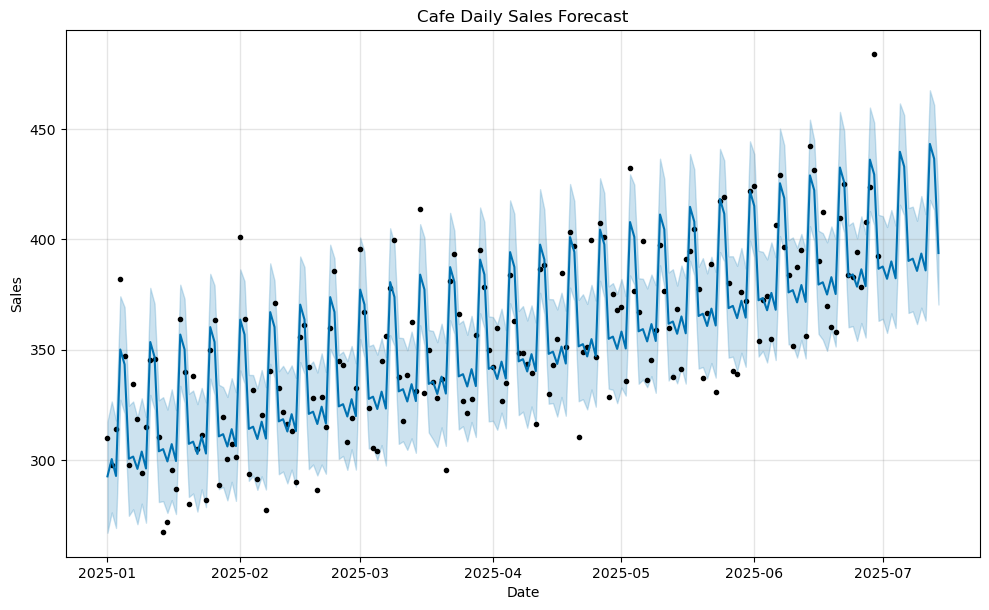

In [7]:
# 8. 예측 그래프 그리기
model.plot(forecast)
plt.title("Cafe Daily Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [8]:
# 9. 2025-07-10 예측값 확인
target_date = pd.to_datetime("2025-07-10")

result = forecast[forecast["ds"] == target_date]

print(result[["ds", "yhat", "yhat_lower", "yhat_upper"]])

            ds       yhat  yhat_lower  yhat_upper
190 2025-07-10  393.51415  369.008034  419.574368
